In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.shape


(8807, 12)

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [8]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [9]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df['duration'].fillna('Unknown', inplace=True)

/tmp/ipykernel_10052/2922871082.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_10052/2922871082.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [12]:
df[['duration_int', 'duration_type']] = df['duration'].str.split(' ', expand=True)
df['duration_int'] = pd.to_numeric(df['duration_int'], errors='coerce')

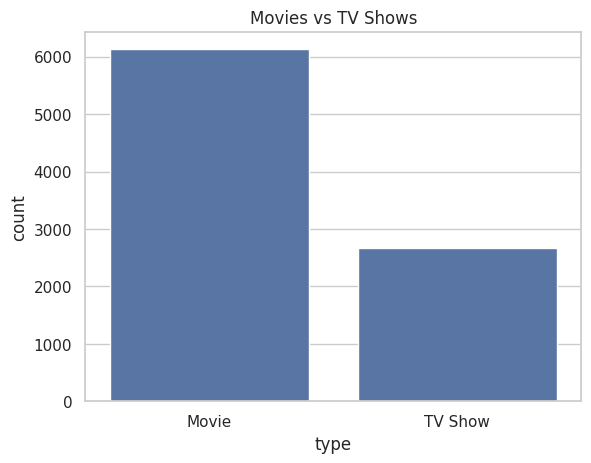

In [13]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

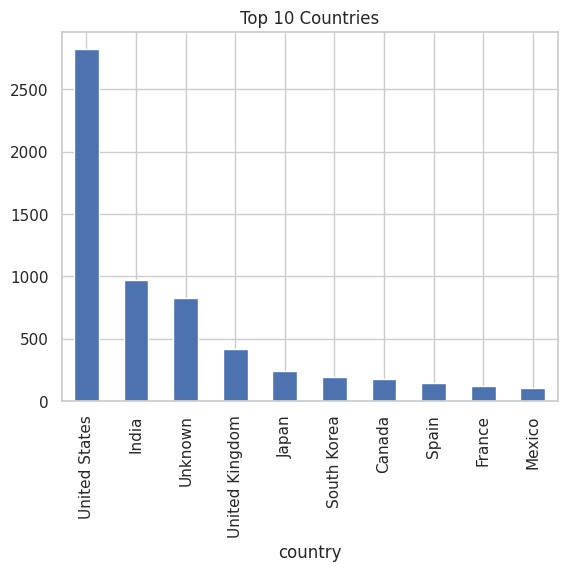

In [14]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

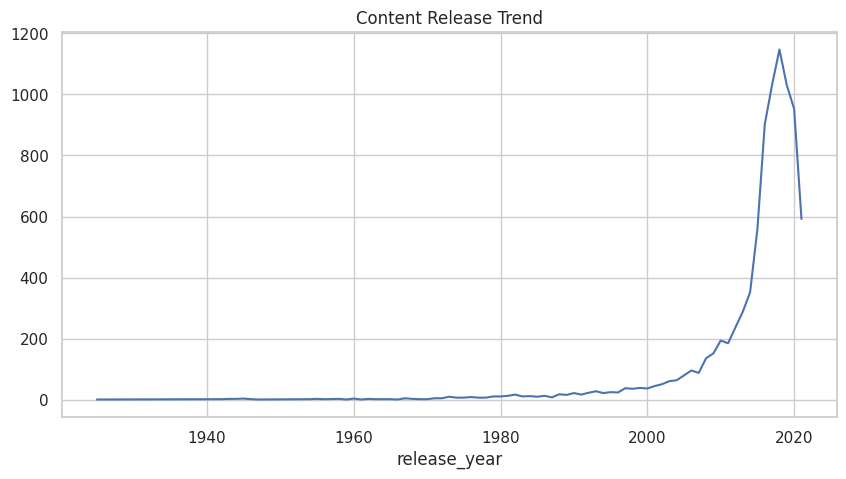

In [15]:
df['release_year'].value_counts().sort_index().plot(figsize=(10,5))
plt.title("Content Release Trend")
plt.show()

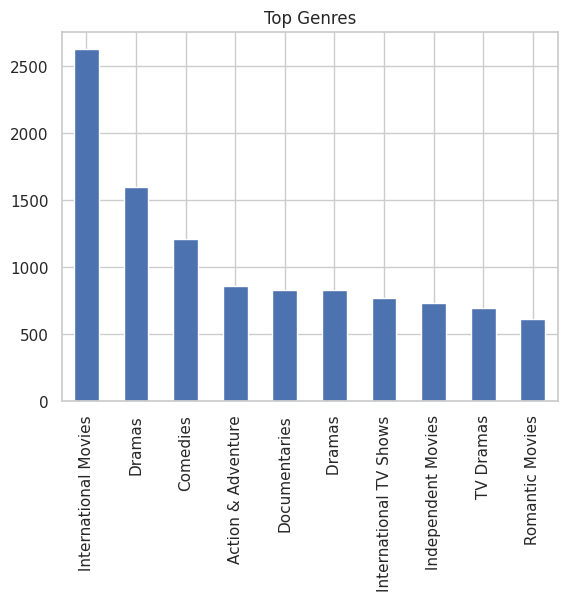

In [16]:
genres = df['listed_in'].str.split(',', expand=True).stack()
genres.value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()

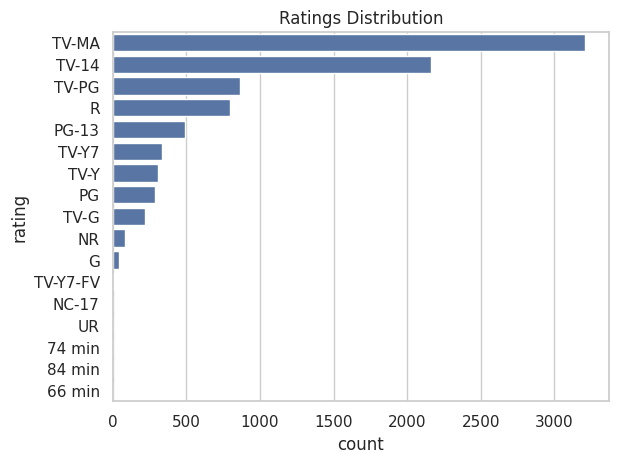

In [17]:
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title("Ratings Distribution")
plt.show()

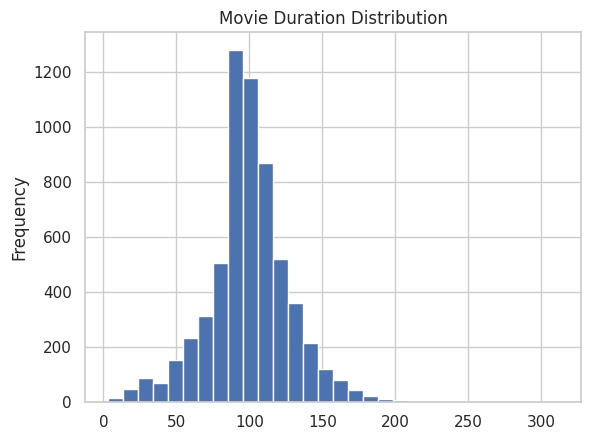

In [18]:
movies = df[df['type'] == 'Movie']
movies['duration_int'].plot(kind='hist', bins=30)
plt.title("Movie Duration Distribution")
plt.show()

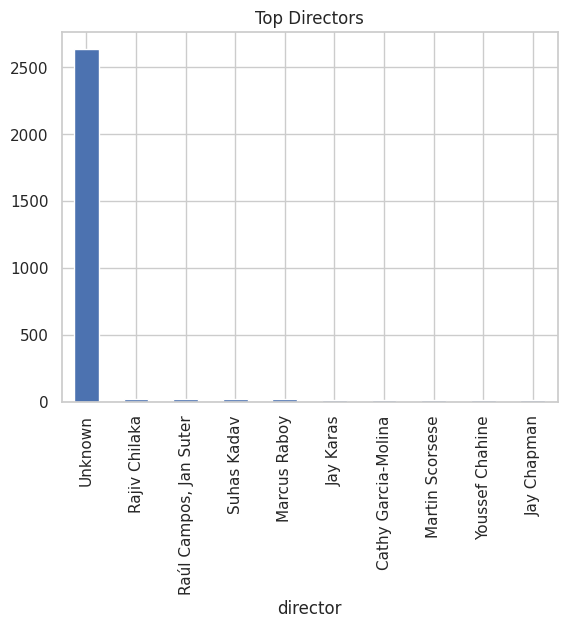

In [19]:
df['director'].value_counts().head(10).plot(kind='bar')
plt.title("Top Directors")
plt.show()

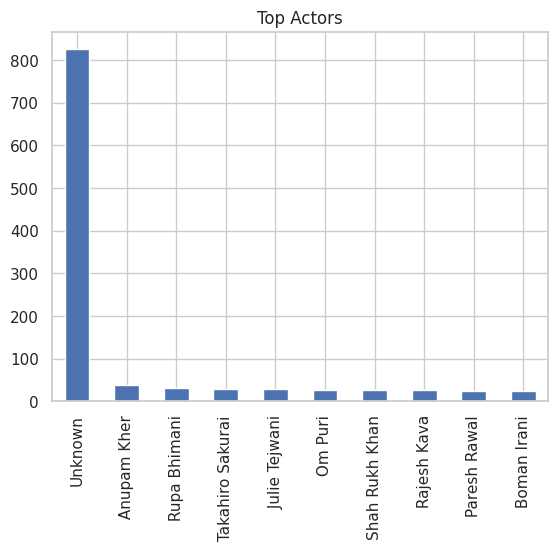

In [20]:
cast = df['cast'].str.split(',', expand=True).stack()
cast.value_counts().head(10).plot(kind='bar')
plt.title("Top Actors")
plt.show()

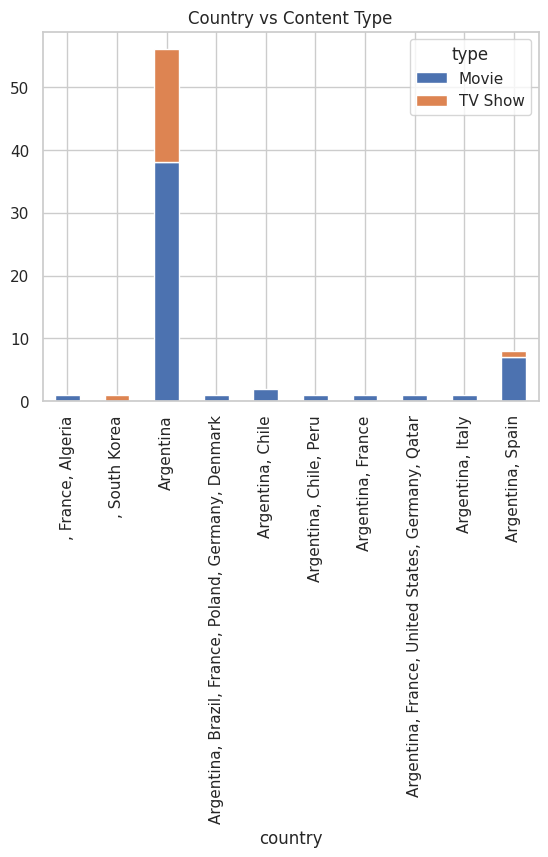

In [21]:
pd.crosstab(df['country'], df['type']).head(10).plot(kind='bar', stacked=True)
plt.title("Country vs Content Type")
plt.show()

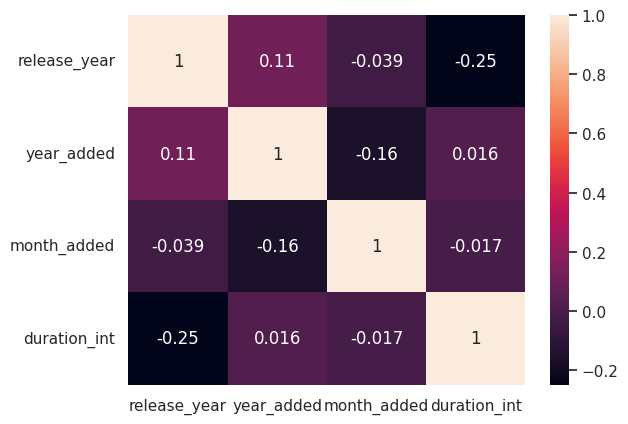

In [22]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

1. Netflix has more Movies than TV Shows.
2. USA contributes the highest content.
3. Content growth increased rapidly after 2015.
4. Drama and Comedy are the most popular genres.
5. Most movies are around 90–120 minutes long.
6. TV-MA and TV-14 are the most common ratings.

Netflix is heavily focused on movie content, especially from the United States.
There has been a sharp increase in content after 2015, showing platform expansion.
Drama and Comedy dominate user preferences.
Netflix can further grow by investing in international and diverse genre content.

In [23]:
df.to_csv("cleaned_netflix_data.csv", index=False)